In [2]:
from astrovision.plot.plot_utils import make_mosaic
from astrovision.data import SatelliteImage, SegmentationLabeledSatelliteImage
import s3fs

In [3]:
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://" + "minio.lab.sspcloud.fr"})
fs.download(rpath="projet-slums-detection/ilots", lpath="ilots", recursive=True)


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [4]:
fs.download(rpath="projet-slums-detection/data-prediction/PLEIADES/MAYOTTE", lpath="pred_mayotte", recursive=True)


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [69]:
import os
import geopandas as gpd

# Open the .gpkg file
pred_2020 = gpd.read_file('pred_mayotte/2020/predictions.gpkg')
pred_2023 = gpd.read_file('pred_mayotte/2023/predictions.gpkg')
# Print the GeoDataFrame
print(pred_2020.head())

                                            filename id  \
0  projet-slums-detection/data-raw/PLEIADES/MAYOT...  0   
1  projet-slums-detection/data-raw/PLEIADES/MAYOT...  1   
2  projet-slums-detection/data-raw/PLEIADES/MAYOT...  2   
3  projet-slums-detection/data-raw/PLEIADES/MAYOT...  3   
4  projet-slums-detection/data-raw/PLEIADES/MAYOT...  4   

                                            geometry  
0  POLYGON ((502603.000 8601994.500, 502604.500 8...  
1  POLYGON ((502548.000 8601986.500, 502550.000 8...  
2  POLYGON ((502596.000 8601974.500, 502601.000 8...  
3  POLYGON ((502591.000 8601970.500, 502591.000 8...  
4  POLYGON ((502602.500 8601981.000, 502606.000 8...  


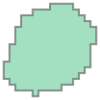

In [8]:
pred_2020.geometry.iloc[12]

In [9]:
pred_2020.crs

<Projected CRS: EPSG:4471>
Name: RGM04 / UTM zone 38S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Mayotte - onshore and offshore.
- bounds: (43.68, -14.49, 46.7, -11.33)
Coordinate Operation:
- name: UTM zone 38S
- method: Transverse Mercator
Datum: Reseau Geodesique de Mayotte 2004
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [81]:
from pyproj import CRS
tgt_crs = CRS.from_epsg(4326)
pred_2020 = pred_2020.to_crs(tgt_crs)
pred_2023 = pred_2023.to_crs(tgt_crs)
ilots = ilots.to_crs(tgt_crs)

In [12]:
! pip install folium

In [13]:
import folium

# Create a Folium map centered on the first polygon in the GeoDataFrame
center = list(pred_2020.iloc[0]['geometry'].centroid.coords)[0]

# initialisation de la carte
m = folium.Map(location=center, zoom_start=10)

# Add a GeoJSON layer from the GeoDataFrame to the map
folium.GeoJson(pred_2020).add_to(m)

In [33]:
pred_2020["area"] = pred_2020.area
pred_2020["area"]

pred_2023["area"] = pred_2023.area
pred_2023["area"]

/tmp/ipykernel_27766/4201852730.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pred_2020["area"] = pred_2020.area
/tmp/ipykernel_27766/4201852730.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pred_2023["area"] = pred_2023.area


0        1.228295e-09
1        5.412826e-10
2        3.185248e-09
3        6.453807e-10
4        8.327495e-10
             ...     
28096    4.167620e-11
28097    1.375315e-09
28098    1.187792e-09
28099    7.497822e-10
28100    1.187172e-09
Name: area, Length: 28101, dtype: float64

In [77]:
ilots = gpd.read_file("ilots/ilots.gpkg")
print(ilots)


      ident_ilot  code depcom_2018  ident_up  \
0      97101AB01  AB01       97101  971_13_2   
1      97101AB02  AB02       97101  971_13_4   
2      97101AB03  AB03       97101  971_13_4   
3      97101AB04  AB04       97101  971_13_4   
4      97101AB05  AB05       97101  971_13_4   
...          ...   ...         ...       ...   
20013  976170405  0405       97617  UP000000   
20014  976170407  0407       97617  UP000000   
20015  976170408  0408       97617  UP000000   
20016  976170409  0409       97617  UP000000   
20017  976170410  0410       97617  UP000000   

                                                geometry  
0      MULTIPOLYGON (((-61.54854 16.26924, -61.54387 ...  
1      MULTIPOLYGON (((-61.53255 16.25634, -61.53273 ...  
2      MULTIPOLYGON (((-61.53561 16.25657, -61.53530 ...  
3      MULTIPOLYGON (((-61.53442 16.25609, -61.53402 ...  
4      MULTIPOLYGON (((-61.53415 16.25671, -61.53399 ...  
...                                                  ...  
20013  MUL

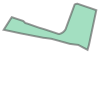

In [45]:
ilots.geometry.iloc[1]

In [52]:
ilots["area"] = ilots.area
ilots["area"]

/tmp/ipykernel_27766/671060319.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ilots["area"] = ilots.area


0        3.029559e-04
1        2.520750e-06
2        7.077846e-07
3        5.035633e-07
4        5.093676e-07
             ...     
20013    5.284700e-06
20014    2.314124e-06
20015    2.753268e-06
20016    3.217506e-04
20017    3.452387e-06
Name: area, Length: 20018, dtype: float64

In [44]:
print(ilots.geometry[1])

MULTIPOLYGON (((-61.532552338579045 16.256335395369828, -61.53272745298164 16.255510786696, -61.53278140476433 16.255253585327598, -61.53284622505223 16.254950140878083, -61.53290387538762 16.254746061686575, -61.53327548171792 16.25494294621939, -61.533340911188816 16.254951307278485, -61.533423873755446 16.254960919428093, -61.53361198459792 16.254984816083486, -61.53435368423152 16.255188779465986, -61.53457391301623 16.255218546105894, -61.53466390077282 16.255227076668692, -61.53559465062822 16.255407489853493, -61.536194235368825 16.255535903154108, -61.53626314008151 16.25554880621721, -61.53594129622041 16.25605382463952, -61.53579312894781 16.25600535232592, -61.53547930329782 16.255901508165408, -61.53544447128261 16.255867375828913, -61.53539513013411 16.25581845684791, -61.53531751323072 16.255797585239605, -61.53495707822232 16.255670823710805, -61.534840427683925 16.255630476771305, -61.53475523471952 16.2556061634122, -61.53463211887221 16.255570290503208, -61.5340773928

In [49]:
def valeurs_extremes(tableau, n, colonne, mode='top'):
    """
    Objectif de la fonction : Sélectionner et renvoyer les n lignes du tableau avec les valeurs les plus hautes ou les plus basses de la colonne spécifiée.
    
    Paramètres :
    - tableau (list): Le tableau de données à traiter. Chaque élément du tableau est supposé être un dictionnaire représentant une ligne de données.
    - n (int): Le nombre de lignes à sélectionner.
    - colonne (str): Le nom de la colonne selon laquelle les valeurs seront comparées.
    - mode (str, optionnel): Le mode de sélection, 'top' pour les valeurs les plus hautes, 'bottom' pour les valeurs les plus basses. Par défaut, 'top'.
    
    Sortie :
    list: Le tableau contenant les n lignes sélectionnées.
    """

    gdf_sorted = tableau.sort_values(by='area', ascending=(mode != 'top'))

    lignes = gdf_sorted.head(n)

    return lignes

In [51]:
print(valeurs_extremes(ilots, 5, 'area', 'top'))

      ident_ilot code_ilot depcom  ident_up  \
12994  97411EW11      EW11  97411  974_03_2   
2027   97120AE09      AE09  97120  971_17_2   
10648  97407AK06      AK06  97407  974_25_2   
10646  97407AK04      AK04  97407  974_25_2   
17687  97420AE29      AE29  97420  974_07_4   

                                                geometry          area  
12994  MULTIPOLYGON (((55.46000 -20.91533, 55.46005 -...  4.424324e-08  
2027   MULTIPOLYGON (((-61.53374 16.24342, -61.53352 ...  6.311771e-08  
10648  MULTIPOLYGON (((55.29765 -20.94419, 55.29787 -...  7.390192e-08  
10646  MULTIPOLYGON (((55.29905 -20.94726, 55.29893 -...  7.841964e-08  
17687  MULTIPOLYGON (((55.60784 -20.90767, 55.60796 -...  8.154587e-08  


In [54]:
print(valeurs_extremes(pred_2020, 5, 'area', 'top'))
print(valeurs_extremes(pred_2023, 5, 'area', 'top'))

                                                filename   id  \
21422  projet-slums-detection/data-raw/PLEIADES/MAYOT...   86   
24444  projet-slums-detection/data-raw/PLEIADES/MAYOT...  167   
21901  projet-slums-detection/data-raw/PLEIADES/MAYOT...   95   
21296  projet-slums-detection/data-raw/PLEIADES/MAYOT...  435   
3627   projet-slums-detection/data-raw/PLEIADES/MAYOT...  144   

                                                geometry      area  
21422  POLYGON ((45.21778 -12.77261, 45.21804 -12.772...  0.000004  
24444  POLYGON ((45.27595 -12.78591, 45.27597 -12.785...  0.000004  
21901  POLYGON ((45.22109 -12.74609, 45.22109 -12.746...  0.000003  
21296  POLYGON ((45.21931 -12.78845, 45.21933 -12.788...  0.000003  
3627   POLYGON ((45.09886 -12.85177, 45.09894 -12.851...  0.000002  
                                                filename   id  \
3435   projet-slums-detection/data-raw/PLEIADES/MAYOT...   77   
21634  projet-slums-detection/data-raw/PLEIADES/MAYOT...  107   


## Découpage des bâtiments pour qu'ils n'appartiennent qu'à un seul îlot

In [85]:
import pandas as pd

nouvelle_table = gpd.GeoDataFrame()
# Corriger les géométries invalides dans ilots
ilots['geometry'] = ilots['geometry'].buffer(0)

# Corriger les géométries invalides dans pred_2020
pred_2020['geometry'] = pred_2020['geometry'].buffer(0)

# Réinitialisez les index des GeoDataFrames
ilots = ilots.reset_index(drop=True)
pred_2020 = pred_2020.reset_index(drop=True)

# Parcourir chaque îlot
for i in range(len(ilots)):
    ilot = ilots.iloc[i]
    
    # Sélectionner les polygones de pred_2020 qui intersectent cet îlot
    polygones_intersectes = pred_2020[pred_2020.intersects(ilot.geometry)]
    
    # Si aucun polygone n'intersecte, passer à l'îlot suivant
    if polygones_intersectes.empty:
        continue
    
    # Effectuer l'intersection entre les polygones de pred_2020 et l'îlot
    polygones_decoupes = polygones_intersectes.intersection(ilot.geometry)
    
    # Ajouter les polygones découpés à la nouvelle table
    nouvelle_table = gpd.GeoDataFrame(pd.concat([nouvelle_table, polygones_decoupes], ignore_index=True))

print(pred_2020.crs)
print(ilots.crs)
print(nouvelle_table.crs)
print(polygones_decoupes.crs)
print(polygones_intersectes.crs)
# Supprimer les lignes de pred_2020 qui sont entièrement incluses dans les îlots
pred_2020_sans_intersection = pred_2020[~pred_2020.within(gpd.GeoSeries(ilots.unary_union))]

# Fusionner les polygones découpés avec les polygones restants de pred_2020
pred_2020_modifie = gpd.GeoDataFrame(pd.concat([nouvelle_table, pred_2020_sans_intersection], ignore_index=True))


EPSG:4326
EPSG:4326


AttributeError: The CRS attribute of a GeoDataFrame without an active geometry column is not defined. Use GeoDataFrame.set_geometry to set the active geometry column.